# 12 확률 과정

## 12.1 난수 생성

In [1]:
import math
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
npr.seed(100)
np.set_printoptions(precision=4)

In [4]:
npr.rand(10)

array([0.5434, 0.2784, 0.4245, 0.8448, 0.0047, 0.1216, 0.6707, 0.8259,
       0.1367, 0.5751])

In [5]:
npr.rand(5, 5)

array([[0.8913, 0.2092, 0.1853, 0.1084, 0.2197],
       [0.9786, 0.8117, 0.1719, 0.8162, 0.2741],
       [0.4317, 0.94  , 0.8176, 0.3361, 0.1754],
       [0.3728, 0.0057, 0.2524, 0.7957, 0.0153],
       [0.5988, 0.6038, 0.1051, 0.3819, 0.0365]])

In [6]:
a = 5.
b = 10.
npr.rand(10) * (b - a) + a

array([9.4521, 9.9046, 5.2997, 9.4527, 7.8845, 8.7124, 8.1509, 7.9092,
       5.1022, 6.0501])

In [7]:
npr.rand(5, 5) * (b - a) + a

array([[7.7234, 8.8456, 6.2535, 6.4295, 9.262 ],
       [9.875 , 9.4243, 6.7975, 7.9943, 6.774 ],
       [6.701 , 5.8904, 6.1885, 5.2243, 7.5272],
       [6.8813, 7.964 , 8.1497, 5.713 , 9.6692],
       [9.7319, 8.0115, 6.9388, 6.8159, 6.0217]])

In [8]:
sample_size = 500

rn1 = npr.rand(sample_size, 3)

rn2 = npr.randint(0, 10, sample_size)

rn3 = npr.sample(size=sample_size)

a = [0, 25, 50, 75, 100]
rn4 = npr.choice(a, size=sample_size)

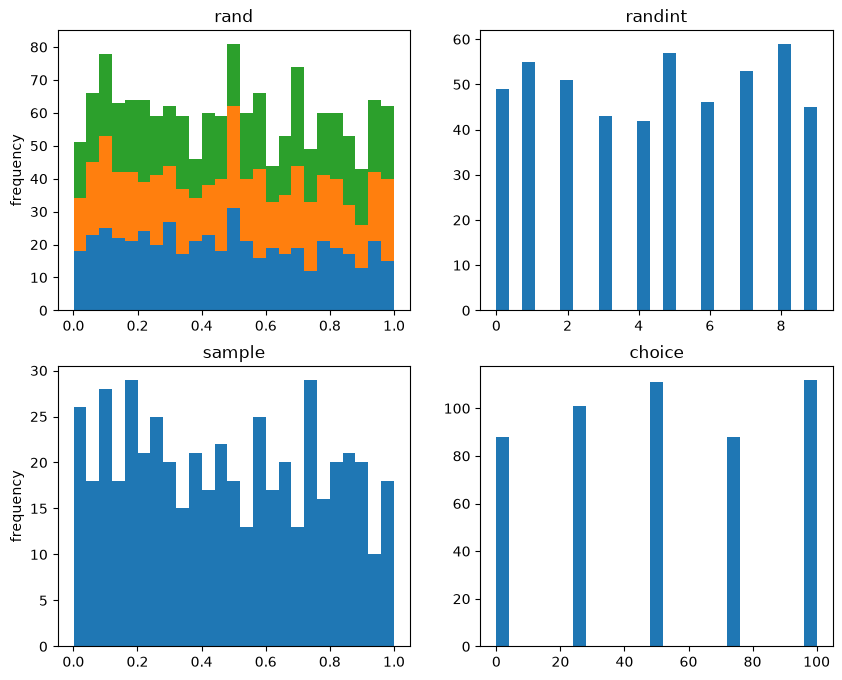

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

ax1.hist(rn1, bins=25, stacked=True)
ax1.set_title('rand')
ax1.set_ylabel('frequency')

ax2.hist(rn2, bins=25)
ax2.set_title('randint')

ax3.hist(rn3, bins=25)
ax3.set_title('sample')
ax3.set_ylabel('frequency')

ax4.hist(rn4, bins=25)
ax4.set_title('choice')

plt.show()

In [10]:
sample_size = 500

rn1 = npr.standard_normal(sample_size)

rn2 = npr.normal(100, 20, sample_size)

rn3 = npr.chisquare(df=0.5, size=sample_size)

rn4 = npr.poisson(lam=1.0, size=sample_size)

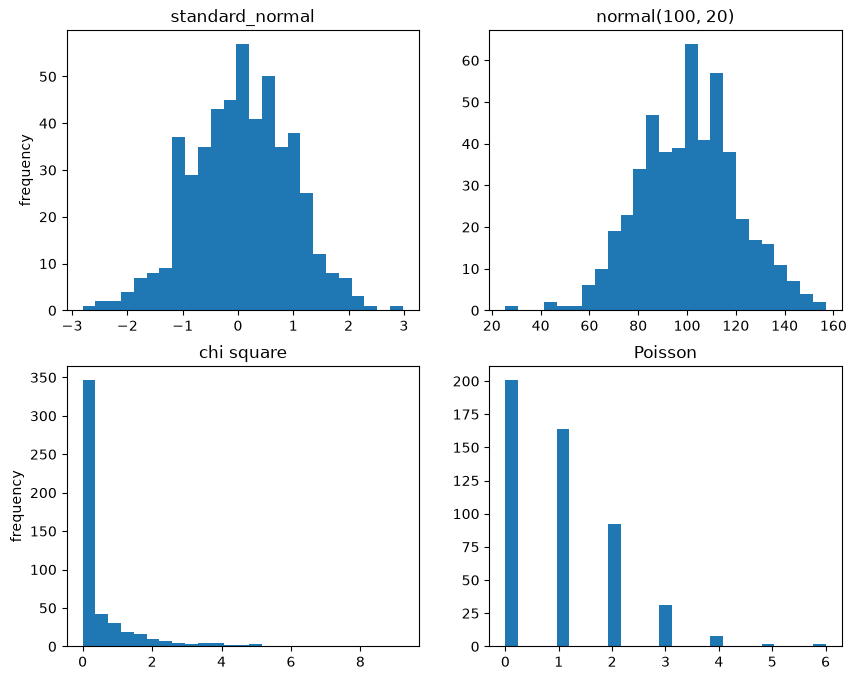

In [11]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

ax1.hist(rn1, bins=25)
ax1.set_title('standard_normal')
ax1.set_ylabel('frequency')

ax2.hist(rn2, bins=25)
ax2.set_title('normal(100, 20)')

ax3.hist(rn3, bins=25)
ax3.set_title('chi square')
ax3.set_ylabel('frequency')

ax4.hist(rn4, bins=25)
ax4.set_title('Poisson')

plt.show()

## 12.2 시뮬레이션

### 12.2.1 확률 변수

**블랙-숄즈-머튼 모형에서의 미래의 주가 시뮬레이션**
- 미래의 특정 시점 $T$에서의 주가 $S_T$를 현 시점의 주가 $S_0$와 수식으로 계산.
- $S_T = S_0 \exp \left( \left( r - \dfrac{1}{2} \sigma^2 \right) T + \sigma \sqrt{T} z \right)$

    - $S_T$: 날짜 $T$에서의 주가
    - $r$: 무위험 단기 이자율
    - $\sigma$: 주가 $S$에 대한 고정 변동성(수익률의 표준편차)
    - $z$: 표준정규분포를 따르는 확률 변수


In [12]:
S0 = 100
r = 0.05
sigma = 0.25
T = 2.0
I = 10000
ST1 = S0 * np.exp((r - 0.5 * sigma * sigma) * T + sigma * math.sqrt(T) * npr.standard_normal(I))

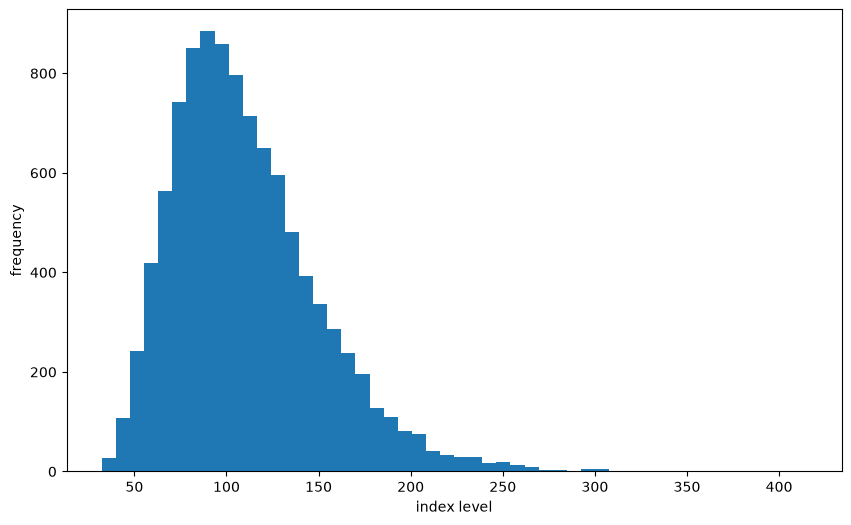

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(ST1, bins=50)

plt.xlabel('index level')
plt.ylabel('frequency')

plt.show()

**로그 정규분포로 정의된 확률변수**
1. 정규분포
- 표준정규분포 난수를 뽑아서 직접 기하 브라운 운동의 만기 가격을 계산.

2. 로그 정규분포
- 어떤 확률변수에 로그를 취했을 때 정규분포가 되는 분포, $\ln X \sim N(\mu, \sigma^2)$

- $X = e^Y, Y \sim N(\mu, \sigma^2)$
- 정규분포를 따르는 값 $Y$에 지수함수 $e^Y$를 씌운 값이 로그 정규분포를 따름

- `np.random.lognormal(mean, sigma, size)`를 사용해서 바로 로그 정규분포 난수를 뽑음.
- $=$ `np.exp(np.random.normal(mean, sigma))`

In [14]:
ST2 = S0 * npr.lognormal((r - 0.5 * sigma * sigma) * T, sigma * math.sqrt(T), size=I)

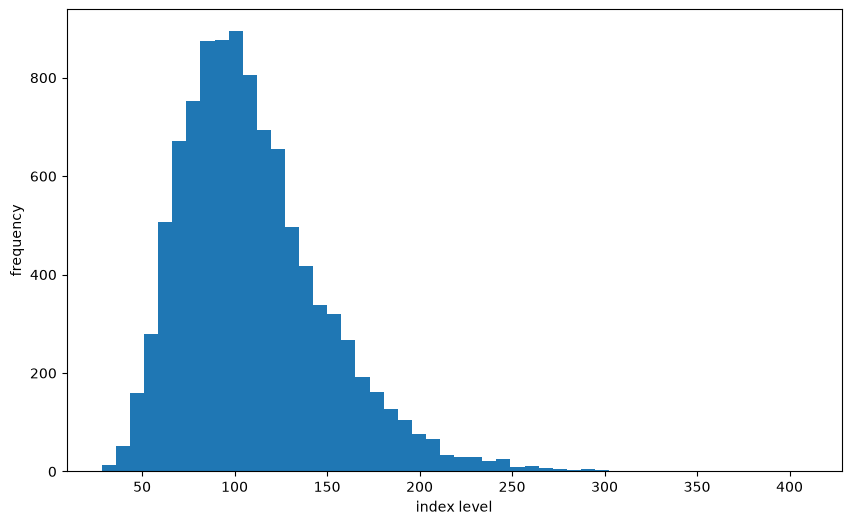

In [15]:
plt.figure(figsize=(10,6))

plt.hist(ST2, bins=50)

plt.xlabel('index level')
plt.ylabel('frequency')

plt.show()

- `scipy.stats` 서브패키지
- `scipy.stats.descrbe()`: 데이터에 대한 중요 통계를 반환

In [16]:
import scipy.stats as scs

In [17]:
def print_statistics(a1, a2):
    ''' 선택된 통계값을 출력

    인수
    ==========
    a1, a2: ndarray 객체
    시뮬레이션에서 나온 결과 객체
    '''
    sta1 = scs.describe(a1)
    sta2 = scs.describe(a2)

    print(f'{'statistic':14s} {'data set 1':14s} {'data set 2':14s}')
    print(45 * "-")
    print(f'{'size':14s} {sta1[0]:14.3f} {sta2[0]:14.3f}')
    print(f'{'min':14s} {sta1[1][0]:14.3f} {sta2[1][0]:14.3f}')
    print(f'{'max':14s} {sta1[1][1]:14.3f} {sta2[1][1]:14.3f}')
    print(f'{'mean':14s} {sta1[2]:14.3f} {sta2[2]:14.3f}')
    print(f'{'std':14s} {np.sqrt(sta1[3]):14.3f} {np.sqrt(sta2[3]):14.3f}')
    print(f'{'skew':14s} {sta1[4]:14.3f} {sta2[4]:14.3f}')
    print(f'{'kurtosis':14s} {sta1[5]:14.3f} {sta2[5]:14.3f}')

In [18]:
print_statistics(ST1, ST2)

statistic      data set 1     data set 2    
---------------------------------------------
size                10000.000      10000.000
min                    32.327         28.230
max                   414.825        409.110
mean                  110.730        110.431
std                    40.300         39.878
skew                    1.122          1.115
kurtosis                2.438          2.217


### 12.2.2 확률 과정

- 확률 과정: 확률 변수의 수열
- 각 단계의 샘플이 독립적이지 않고 이전의 결과들에 의존한다는 차이점.
- **마코프(Markov) 특성**: 미래 값이 바로 전의 과거 값에만 의존하고 그보다 더 과거의 값이나 전체 경로에는 의존하지 않음.
- **무기억성(memoryless) 확률 과정**


**기하 브라운 운동 모형**

블랙-숄즈-머튼 모형: 아래 확률 미분방정식(SDE, stochastic differential equation)을 따르는 동적인 형태의 모형

확률 미분방정식: **기하 브라운 운동**
- $d S_t = r S_t dt + \sigma S_t dZ_t$

    - $Z_t$는 표준 브라운 운동 과정의 값
    - $S_t$값은 로그 정규분포를 따르고,
    - 수익률 $\dfrac{dS_t}{S_t}$는 정규분포를 따름.

확률 미분방적식을 오일러 방식(Euler scheme)으로 정확히 이산화(discretization)할 수 있음.
- $S_t = S_{t - \Delta t} \exp \left( \left( r - \dfrac{1}{2} \sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} z_t \right)$

    - $\Delta t$: 고정된 시간 이산화 간격,
    - $z_t$: 정규분포를 따르는 확률 변수

In [19]:
I = 10000
M = 50
dt = T / M
S = np.zeros((M + 1, I))
S[0] = S0
for t in range(1, M + 1):
    S[t] = S[t - 1] * np.exp((r - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * npr.standard_normal(I))

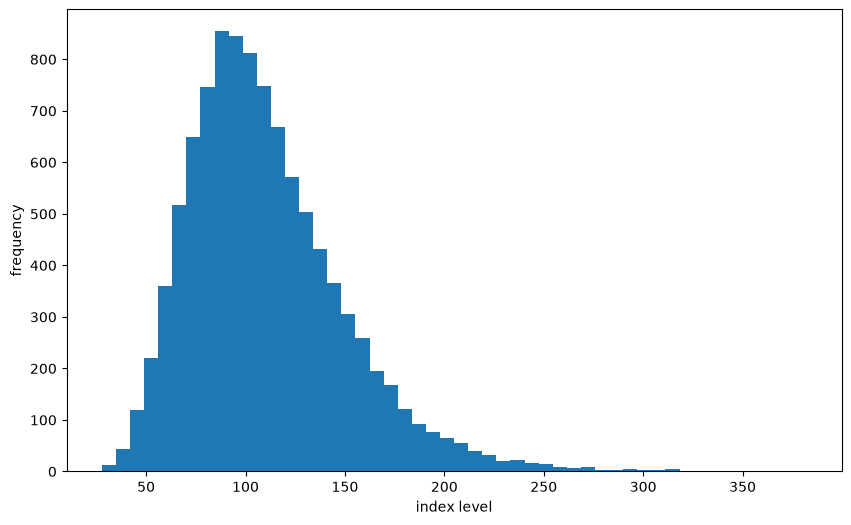

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(S[-1], bins=50)
plt.xlabel('index level')
plt.ylabel('frequency')
plt.show()

In [21]:
print_statistics(S[-1], ST2)

statistic      data set 1     data set 2    
---------------------------------------------
size                10000.000      10000.000
min                    27.746         28.230
max                   382.096        409.110
mean                  110.423        110.431
std                    39.179         39.878
skew                    1.069          1.115
kurtosis                2.028          2.217


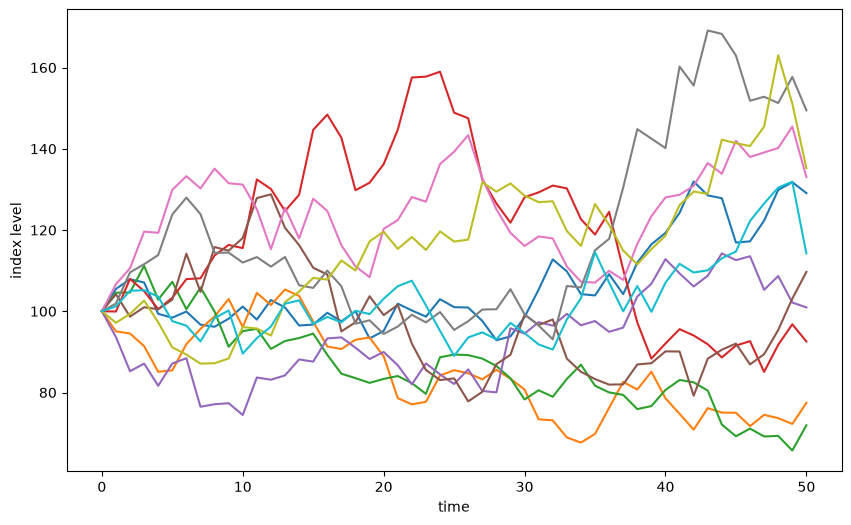

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(S[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level')
plt.show()

**제곱근 확산 모형**

**평균 회귀 과정(mean-reverting process)**: 단기 이자율이나 변동성 모형에서 사용

**제곱근 확산(square-root diffusion) 모형**: 평균 회귀 과정에서 가장 널리 사용되는 모형

제곱근 확산 확률 미분방정식

- $dx_t = \kappa ( \theta - x_t ) dt + \sigma \sqrt{x_t} d Z_t$

    - $x_t$: 시간 $t$에서의 확률 과정 값

    - $\kappa$: 평균 회귀계수

    - $\theta$: 확률 과정의 장기 평균

    - $\sigma$: 고정 변동성

    - $Z_t$: 표준 브라운 운동

많은 금융 공학 모형이 이산화가 가능하고 정규분포로 근사화가 가능.
오일러 방식은 기하 브라운 운동 모형에만 정확히 적용 가능하고, 대부분의 다른 확률 과정에서는 편향 오차를 가짐.

제곱근 확산 모형에 대해서도 정확한 이산 방법이 존재하기는 하지만 오일러 방식을 사용하는 쪽이 계산상 장점이 많음.

$s = t - \Delta t$와 $x^+ \equiv \max(x, 0)$로 정의하면 오일러 방식을 적용.

**풀 트렁케이션 (full truncation) 이산화 방식**

제곱근 확산 모형의 오일러 이산화

- $\tilde{x}_t = \tilde{x}_s + \kappa(\theta - \tilde{x}^+_s) \Delta t + \sigma \sqrt{\tilde{x}^+_s} \sqrt{\Delta t} z_t$
- $\tilde{x}_t = \tilde{x}^+_s$

제곱근 확산 모형은 $x_t$ 값이 항상 양수로 유지된다는 현실적이고 편리한 특성.

하지만 단순 오일러 방식으로 이산화하면 음수가 될 가능성이 생기기 때문에 원래의 시뮬레이션 값에서 양수만을 취하는 방식을 사용

따라서 시뮬레이션 코드에도 확률 과정의 값을 저장하기 위해 하나가 아닌 두 개의 ndarray 객체가 필요.

In [23]:
x0 = 0.05
kappa = 3.0
theta = 0.02
sigma = 0.1
I = 10000
M = 50
dt = T / M

In [24]:
def srd_euler():
    xh = np.zeros((M + 1, I))
    x = np.zeros_like(xh)
    xh[0] = x0
    x[0] = x0
    for t in range(1, M + 1):
        xh[t] = xh[t - 1] + kappa * (theta - np.maximum(xh[t - 1], 0)) * dt+ sigma * np.sqrt(np.maximum(xh[t - 1], 0)) * math.sqrt(dt) * npr.standard_normal(I)
    x = np.maximum(xh, 0)
    return x
x1 = srd_euler()

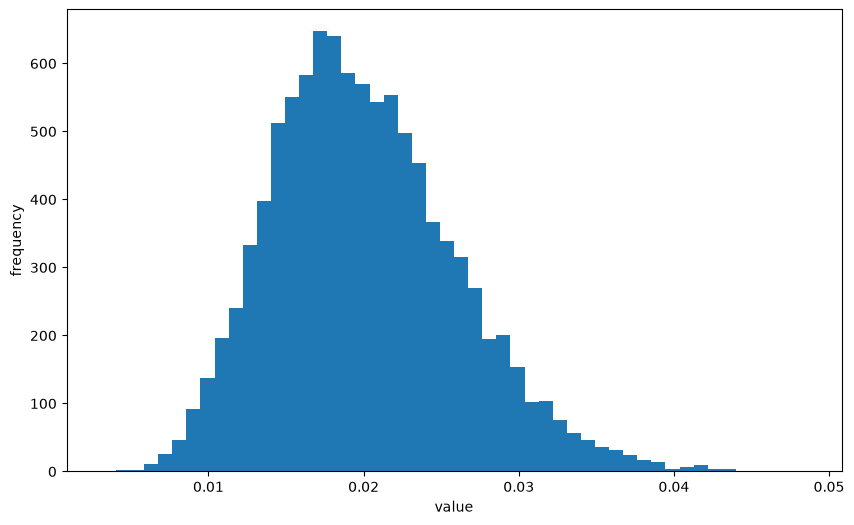

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(x1[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

현재 값이 장기 평균 $\theta = 0.02$보다 높기 때문에 $(x_0 > \theta)$ 표류 경향(drift)이 음수, 장기 평균으로 수렴

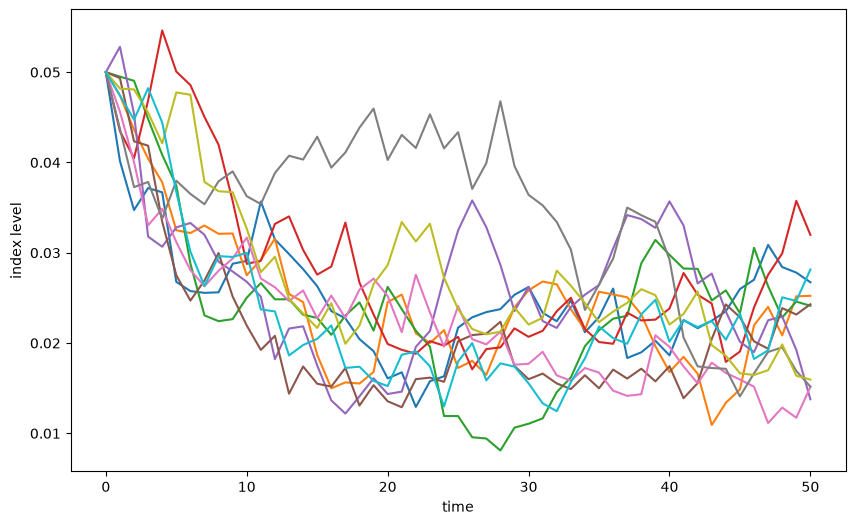

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(x1[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level')
plt.show()

제곱근 확산 모형의 정확한 이산화

- $x_t = \dfrac{\sigma^2 (1 - e^{-\kappa \Delta t})}{4 \kappa} X^{'2}_d \left( \dfrac{4 \kappa e^{-\kappa \Delta t}}{\sigma^2 (1 - e^{-\kappa \Delta t})} x_S \right)$

확률 과정을 완벽하게 이산화 시뮬레이션.

제곱근 확산 모형을 자유도 $df = \dfrac{4 \theta \kappa}{\sigma^2}$와 비중심 인수 $nc = \dfrac{4 \kappa e^{-\kappa \Delta t}}{\sigma^2 (1 - e^{-\kappa \Delta t})}x_s$를 가진 비중심 카이 제곱 분포로 표현

In [27]:
def srd_exact():
    x = np.zeros((M + 1, I))
    x[0] = x0
    for t in range(1, M + 1):
        df = 4 * theta * kappa / (sigma * sigma)
        nc = 4 * kappa * np.exp(-kappa * dt) * x[t - 1] / (sigma * sigma * (1 - np.exp(-kappa * dt)))
        x[t] = (sigma * sigma * (1 - np.exp(-kappa * dt)) / (4 * kappa)) * npr.noncentral_chisquare(df, nc, I)
    return x
x2 = srd_exact()

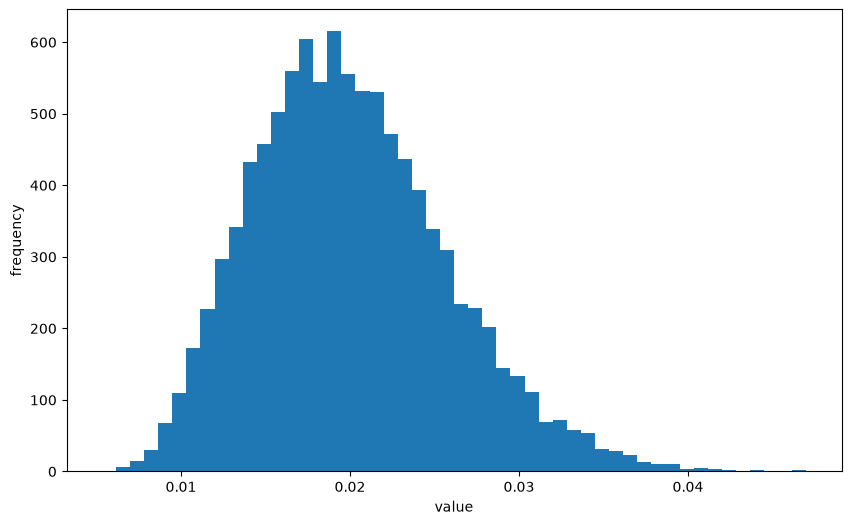

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(x2[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

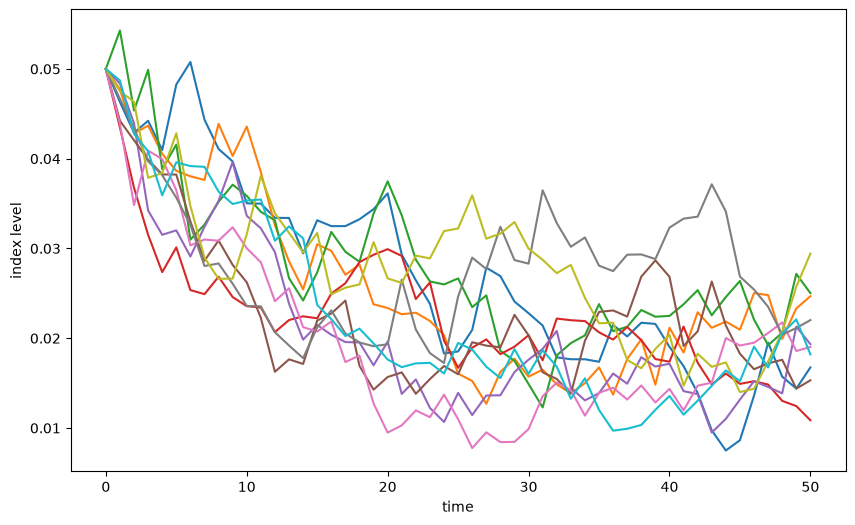

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(x2[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level')
plt.show()

In [30]:
print_statistics(x1[-1], x2[-1])

statistic      data set 1     data set 2    
---------------------------------------------
size                10000.000      10000.000
min                     0.003          0.005
max                     0.049          0.047
mean                    0.020          0.020
std                     0.006          0.006
skew                    0.529          0.532
kurtosis                0.289          0.273


In [31]:
I = 250000
%time x1 = srd_euler()

CPU times: user 138 ms, sys: 29.9 ms, total: 168 ms
Wall time: 168 ms


In [32]:
%time x2 = srd_exact()

CPU times: user 311 ms, sys: 18 ms, total: 329 ms
Wall time: 329 ms


In [33]:
print_statistics(x1[-1], x2[-1])

statistic      data set 1     data set 2    
---------------------------------------------
size               250000.000     250000.000
min                     0.002          0.003
max                     0.071          0.055
mean                    0.020          0.020
std                     0.006          0.006
skew                    0.563          0.579
kurtosis                0.492          0.520


**확률적 변동성 모형**

블랙-숄즈-머튼 모형의 최대 단순 가정 중 하나는 변하지 않는 변동성.
그러나 일반적으로 변동성은 고정되어 있지도 않고 결정론적이지 않은 확률적인 값.

**확률적 변동성 모형(stochastic volatility model)**

헤스톤 모형의 확률 미분방정식

$dS_t = r S_t dt + \sqrt{v_t} S_t dZ^1_t$

$dv_t = \kappa_v (\theta - v_t) dt + \sigma_v \sqrt{v_t} dZ^2_t$

$dZ^1_t dZ^2_t = \rho$

인수 $\rho$는 두 표준 브라운 운동 $Z^1_t, Z^2_t$의 순간 상관계수(instantaneous correlation)를 나타냄.

상관계수를 통해 시장이 하락할 때 변동성이 증가하고, 시장이 상승할 때 변동성이 감소하는 이른 바 **레버리지 효과**(leverage effect)를 설명하는 것이 가능.

두 확률 과정의 상관관계를 구하려면 상관계수 행렬(correlation matrix)에 대한 숄레스키 분해(Cholesky decomposition)가 필요.

In [34]:
S0 = 100.
r = 0.05
v0 = 0.1
kappa = 3.0
theta = 0.25
sigma = 0.1
rho = 0.6
T = 1.0

In [35]:
corr_mat = np.zeros((2, 2))
corr_mat[0, :] = [1.0, rho]
corr_mat[1, :] = [rho, 1.0]
cho_mat = np.linalg.cholesky(corr_mat) # 행렬의 숄레스키 분해

In [36]:
cho_mat

array([[1. , 0. ],
       [0.6, 0.8]])

1. 변동성의 확률 과정

시뮬레이션에 사용될 난수를 미리 생성.

집합 0은 주가의 확률 과정, 집합 1은 변동성의 확률 과정에서 사용.

제곱근 확산 모형에 기반한 변동성 과정에 대해서는 상관관계를 고려한 오일러 이산화 방식을 사용

In [37]:
M = 50
I = 10000
dt = T / M

In [38]:
ran_num = npr.standard_normal((2, M + 1, I ))

In [39]:
v = np.zeros_like(ran_num[0])
vh = np.zeros_like(v)

In [40]:
v[0] = v0
vh[0] = v0

In [41]:
for t in range(1, M + 1):
    ran = np.dot(cho_mat, ran_num[:, t, :]) # 관련 있는 난수만 고르고 숄레스키 행렬로 변환
    vh[t] = vh[t-1] + kappa * (theta - np.maximum(vh[t - 1], 0)) * dt + sigma * np.sqrt(np.maximum(vh[t - 1], 0)) * math.sqrt(dt) * ran[1]

In [42]:
v = np.maximum(vh, 0)

2. 주가의 확률 과정

마찬가지로 상관관계를 고려하고 기하 브라운 운동에 대해 정확한 형태의 오일러 방식으로 이산화

In [43]:
S = np.zeros_like(ran_num[0])
S[0] = S0
for t in range(1, M + 1):
    ran = np.dot(cho_mat, ran_num[:, t, :])
    S[t] = S[t - 1] * np.exp((r - 0.5 * v[t]) * dt + np.sqrt(v[t]) * np.sqrt(dt) * ran[0])

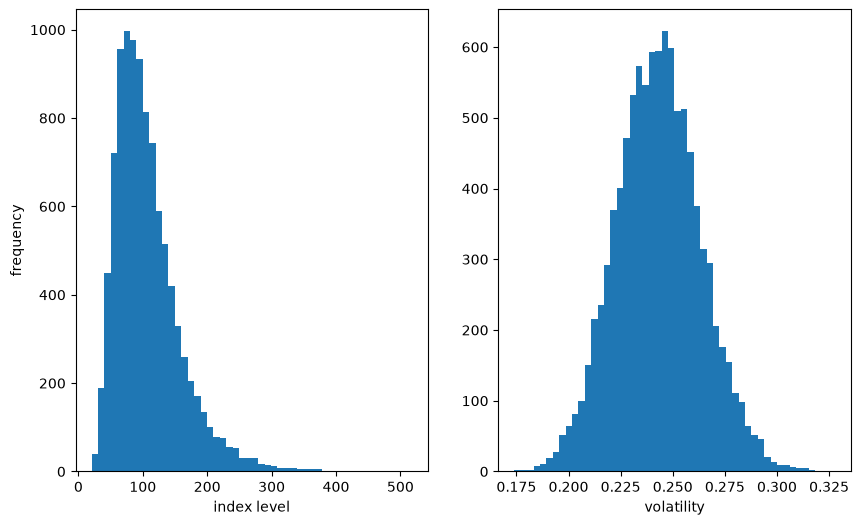

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.hist(S[-1], bins=50)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax2.hist(v[-1], bins=50)
ax2.set_xlabel('volatility')
plt.show()

제곱근 확산 모혀에 오일러 방식을 사용하는 것이 좋은 이유

오일러 방식을 사용하면 표준정규분포를 사용하므로 샘플 생성 시 **상관관계를 간단하고 일관적으로 적용**

만약에 주가 과정에는 오일러 방식을 사용하고 변동성 과정에는 비중심 카이 제곱에 기반한 방식을 사용한다면 상관관계를 일관성 있게 적용하기 어려움. 

In [45]:
print_statistics(S[-1], v[-1])

statistic      data set 1     data set 2    
---------------------------------------------
size                10000.000      10000.000
min                    20.556          0.174
max                   517.798          0.328
mean                  107.843          0.243
std                    51.341          0.020
skew                    1.577          0.124
kurtosis                4.306          0.048


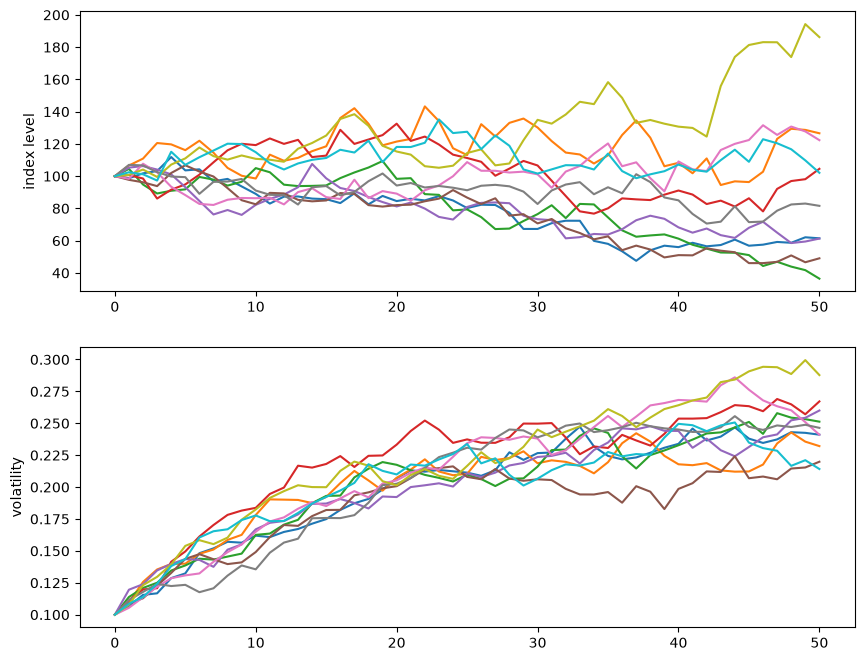

In [46]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
ax1.plot(S[:, :10], lw=1.5)
ax1.set_ylabel('index level')
ax2.plot(v[:, :10], lw=1.5)
ax2.set_ylabel('volatility')
plt.show()

**점프 확산**

자산 가격이나 변동성이 점프하는 현상

로그 정규분포에 점프 요인을 더하여 블랙-숄즈-머튼 모형을 개선한 점프 확산 (jump diffusion) 모형

점프 확산 모형의 확률 미분방정식

- $dS_t = (r - r_j) S_t dt + \sigma S_t dZ_t + J_t S_t dN_t$

    - $S_t$: 시간 $t$에서의 주가

    - $r$: 고정 무위험 단기 이자율

    - $r_j \equiv \lambda \cdot \left( e^{\mu_j + \delta^2 / 2} - 1 \right)$: 점프의 위험 중립성을 보존하기 위한 표류계수 수정항

    - $\sigma$: $S$의 고정 변동성

    - $Z_t$: 표준 브라운 운동

    - $J_t$: 시간 $t$에서의 점프, 다음과 같은 분포를 가짐.

        - $\log{1 + J_t} = N \left( \log{1 + \mu_j} - \dfrac{\delta^2}{2}, \delta^2 \right)$, $N$은 표준정규분포의 누적 분포 함수
    
    - $N_t$: 점프 강도 $\lambda$를 가지는 포아송 과정

점프 확산 모형의 오일러 이산화

- $S_t = S_{t - \Delta t} \left( e^{(r - r_j - \sigma^2 / 2) \Delta t + \sigma \sqrt{\Delta t} z^1_t} + \left( e^{\mu_J + \delta z^2_t} - 1 \right) y_t \right)$

In [47]:
S0 = 100.
r = 0.05
sigma = 0.2
lamb = 0.75 # 점프 강도
mu = -0.6 # 평균 점프 크기
delta = 0.25 # 점프 변동성
rj = lamb * (math.exp(mu + 0.5 *delta * delta) - 1) # 표류계수 수정치

In [48]:
T = 1.0
M = 50
I = 10000
dt = T / M

점프 확산 모형을 시뮬레이션하려면 세 개의 독립적인 난수 집합이 필요

In [49]:
S = np.zeros((M + 1, I))

S[0] = S0

sn1 = npr.standard_normal((M + 1, I)) # 표준정규분포 난수
sn2 = npr.standard_normal((M + 1, I)) # 표준정규분포 난수
poi = npr.poisson(lamb * dt, (M + 1, I)) # 포아송 분포 난수

for t in range(1, M + 1):
    S[t] = S[t - 1] * (np.exp((r - rj - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * sn1[t]) + (np.exp(mu + delta * sn2[t]) - 1) * poi[t]) # 정확한 오일러 방식에 따른 시뮬레이션
    S[t] = np.maximum(S[t], 0)

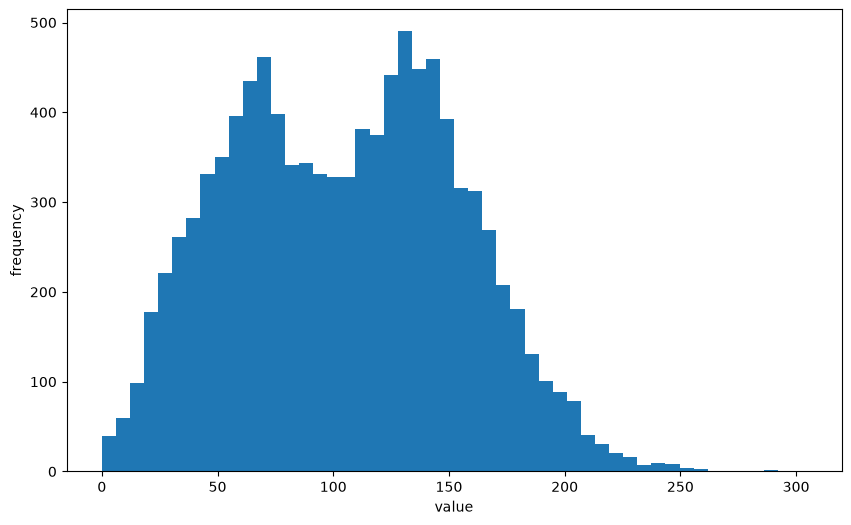

In [50]:
plt.figure(figsize=(10, 6))
plt.hist(S[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

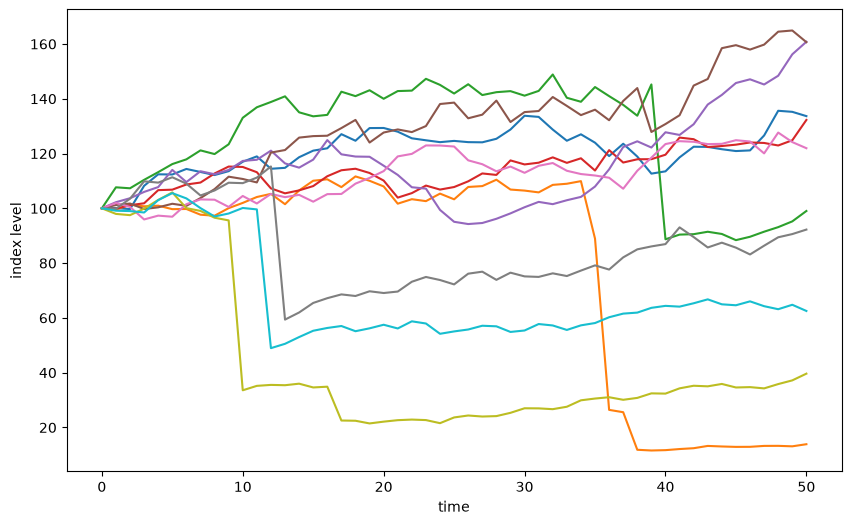

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(S[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level')
plt.show()

### 12.2.3 분산 감소

**의사 난수**를 생성하고 샘플의 수도 계속 달라지기 때문에 결과로 나온 숫자들이 기대하거나 원했던 통계적 특성을 충분하게 보이지 않을 수 있음.

In [52]:
print(f'{'Mean':15s} {'Std. Deviation':15s}')
print(31 * '-')
for i in range(1, 31, 2):
    npr.seed(100)
    sn = npr.standard_normal(i ** 2 * 10000)
    print(f'{sn.mean():15.12f} {sn.std():15.12f}')

Mean            Std. Deviation 
-------------------------------
 0.001150944833  1.006296354600
 0.002841204001  0.995987967146
 0.001998082016  0.997701714233
 0.001322322067  0.997771186968
 0.000592711311  0.998388962646
-0.000339730751  0.998399891450
-0.000228109010  0.998657429396
 0.000295768719  0.998877333340
 0.000257107789  0.999284894532
-0.000357870642  0.999456401088
-0.000528443742  0.999617831131
-0.000300171536  0.999445228838
-0.000162924037  0.999516059328
 0.000135778889  0.999611052522
 0.000182006048  0.999619405229


In [53]:
i ** 2 * 10000

8410000

표준정규분포의 처음 두 모멘트값을 개선하고 어렵지 않게 구현할 수 있는 분산 감소 (variance reduction) 방법 존재.

1. **대조 변수** (antithetic variates)

난수를 원하는 수의 절반만 생성하고 생성된 숫자의 부호를 반대로 한 난수를 추가로 포함하는 방법.

이 방법을 쓰면 평균값이 정확하게 0

`np.concatenate()` 함수로 구현.

In [54]:
sn = npr.standard_normal(int(10000 / 2))
sn = np.concatenate((sn, -sn))

In [55]:
np.shape(sn)

(10000,)

In [56]:
sn.mean()

np.float64(0.0)

In [57]:
print(f'{'Mean':15s} {'Std. Deviation':15s}')
print(31 * '-')
for i in range(1, 31, 2):
    npr.seed(1000)
    sn = npr.standard_normal(i ** 2 * int(10000 / 2))
    sn = np.concatenate((sn, -sn))
    print(f'{sn.mean():15.12f} {sn.std():15.12f}')

Mean            Std. Deviation 
-------------------------------
 0.000000000000  1.009653753942
 0.000000000000  1.000413716783
 0.000000000000  1.002925061201
 0.000000000000  1.000755212673
 0.000000000000  1.001636910076
 0.000000000000  1.000726758438
 0.000000000000  1.001621265149
 0.000000000000  1.001203722778
 0.000000000000  1.000556669784
 0.000000000000  1.000113464185
 0.000000000000  0.999435175324
 0.000000000000  0.999356961431
 0.000000000000  0.999641436845
 0.000000000000  0.999642768905
 0.000000000000  0.999638303451


2. **모멘트 정합**(moment matching)

1차와 2차 모멘트를 같이 수정할 수 있음.

In [58]:
sn = npr.standard_normal(10000)

In [59]:
sn.mean()

np.float64(-0.0011659982951624946)

In [60]:
sn.std()

np.float64(0.991255920204605)

In [61]:
sn_new = (sn - sn.mean()) / sn.std()

In [62]:
sn_new.mean()

np.float64(-2.3803181647963357e-17)

In [63]:
sn_new.std()

np.float64(0.9999999999999999)

각각의 분산 감소 방법을 이용하여 표준정규분포를 따르는 난수를 생성하는 함수

In [64]:
def gen_sn(M, I, anti_paths=True, mo_match=True):
    ''' Function to generate random numbers for simulation.

    인수
    ==========
    M: int
        number of time intervals for discretization
    I: int
        number of paths to be simulated
    anti_paths: boolean
        use of antithetic variates
    mo_match: boolean
        use of moment matching
    '''
    if anti_paths is True:
        sn = npr.standard_normal((M + 1, int(I / 2)))
        sn = np.concatenate((sn, -sn), axis=1)
    else:
        sn = npr.standard_normal((M + 1, I))
    
    if mo_match is True:
        sn = (sn - sn.mean()) / sn.std()
    
    return sn

## 12.3 가치 평가

몬테카를로 시뮬레이션의 가장 중요한 응용: 

옵션, 파생상품, 하이브리드 상품 등의 **조건부 청구권** (contingent claims)의 가치를 평가하는 것.

조건부 청구권의 가치 = 위험 중립 또는 마틴게일 측도 (risk neutral(martingale measure)) 하에서 기대 페이오프를 할인한 것과 같음. 

위험 중립 측도는 주식, 지수 등의 모든 위험 요인이 무위험 단기 이자율에 따라 증가하도록 하여 할인된 확률 과정이 마틴게일이 되게 하는 확률 측도.

자산 가격결정 기본 정리(fundamental theorem of asset pricing)에 따르면 위험 중립 측도의 존재는 무위험 차익 거래의 부존재(absence of arbitrage)와 같음. 

### 12.3.1 유러피안 옵션

유러피안 콜 옵션의 만기 페이오프는 $h(S_T) \equiv \max{S_T - K, 0}$로 주어짐.

$S_T$는 만기에서의 주가, $T$는 만기, $K는 행사가$.

만약 (기하 브라운 운동 등의) 관련 확률 과정에 대한 위험 중립 측도가 존재한다면(이를 완전 시장이 존재한다고 함) 이 옵션의 가격은 - 

위험 중립 기댓값을 사용한 가격결정

- $C_0 = e^{-rT} E^Q_0 (h(S_T)) = e^{-rF} \int^{\infty}_0 h(s) q(s) ds$

유러피안 옵션을 몬테카를로 방식으로 추정하는 방법 - 

위험 중립 몬테카를로 추정법

- $\tilde{C_0} = e^{-rT} \dfrac{1}{I} \sum\limits_{i=1}^{I} h(\tilde{S^i_T})$

In [65]:
S0 = 100
r = 0.05
sigma = 0.25
T = 1.0
I = 50000

In [66]:
def gbm_mcs_stat(K):
    ''' 몬테 카를로 시뮬레이션에 의한 유러피안 콜 옵션의 가치 평가
    
    인수
    ==========
    K: float
        (양의) 옵션 행사가

    반환값
    ==========
    C0: float
        유러피안 콜 옵션의 현재 추정 가치
    '''
    sn = gen_sn(1, I)

    # 만기에서의 지수 수준 시뮬레이면
    ST = S0 * np.exp((r - 0.5 * sigma * sigma) * T + sigma * math.sqrt(T) * sn[1])

    # 만기에서의 페이오프 계산
    hT = np.maximum(ST - K, 0)

    # 몬테카를로 시뮬레이션 계싼
    C0 = math.exp(-r * T) * np.mean(hT)
    
    return C0

In [67]:
gbm_mcs_stat(K=105.)

np.float64(10.044221852841922)

In [68]:
M = 50

In [69]:
def gbm_mcs_dyna(K, option='call'):
    ''' 몬테카를로 시뮬레이션에 의한 유러피안 옵션의 가치 평가

    인수
    ==========
    K: float
        (양의) 옵션 행사가
    option: string
        가치를 평가할 옵션의 유형 ('call', 'put')
    
    반환값
    ==========
    C0: float
        유러피안 옵션의 현재 추정 가치
    '''
    dt = T / M

    # 지수 수준의 시뮬레이션
    S = np.zeros((M + 1, I))
    S[0] = S0
    sn = gen_sn(M, I)
    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp((r - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * sn[t])
    
    # 옵션 유형에 따른 페이오프 계산
    if option == 'call':
        ht = np.maximum(S[-1] - K, 0)
    else:
        ht = np.maximum(K - S[-1], 0)
    
    # 몬테카를로 시뮬레이션 계산
    C0 = math.exp(-r * T) * np.mean(ht)
    return C0

In [70]:
gbm_mcs_dyna(K=110., option='call')

np.float64(7.950008525028437)

In [71]:
gbm_mcs_dyna(K=110., option='put')

np.float64(12.629934942682002)

시뮬레이션 방식으로 계산한 값이 블랙-숄즈-머튼 가치 평가 공식으로 계산한 벤치마크값과 얼마나 일치하는가

`bsm_function.py` 모듈의 블랙-숄즈-머튼 해석 공식을 사용하여 다양한 행사가에 대한 상대적 옵션 가격을 계산

In [72]:
from bsm_functions import bsm_call_value

In [73]:
stat_res = []
dyna_res = []
anal_res = []
k_list = np.arange(80., 120.1, 5.)
np.random.seed(100)

In [74]:
for K in k_list:
    stat_res.append(gbm_mcs_stat(K))
    dyna_res.append(gbm_mcs_dyna(K))
    anal_res.append(bsm_call_value(S0, K, T, r, sigma))

In [75]:
stat_res = np.array(stat_res)
dyna_res = np.array(dyna_res)
anal_res = np.array(anal_res)

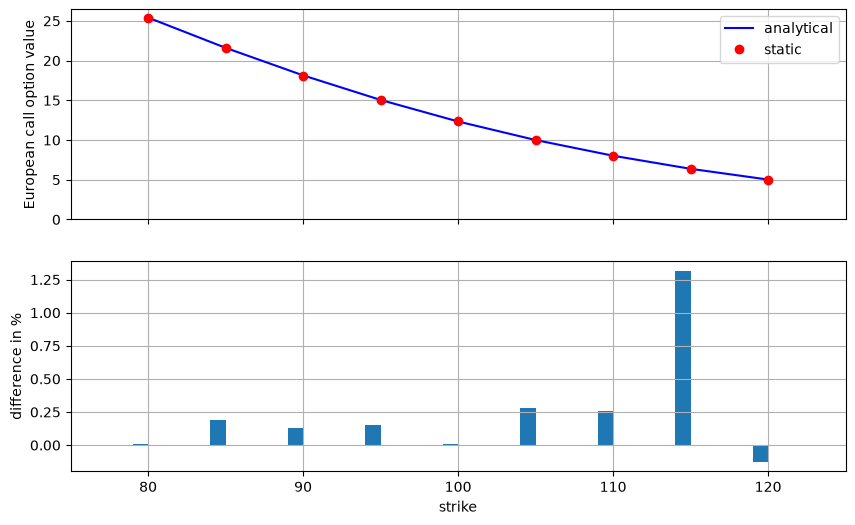

In [76]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,6))

ax1.plot(k_list, anal_res, 'b', label='analytical')
ax1.plot(k_list, stat_res, 'ro', label='static')
ax1.set_ylabel('European call option value')
ax1.legend(loc=0)
ax1.set_ylim(bottom=0)
ax1.grid(True)

wi = 1.0
ax2.bar(k_list - wi / 2, (anal_res - stat_res) / anal_res * 100, wi)
ax2.set_xlabel('strike')
ax2.set_ylabel('difference in %')
ax2.set_xlim(left=75, right=125)
ax2.grid(True)

plt.show()

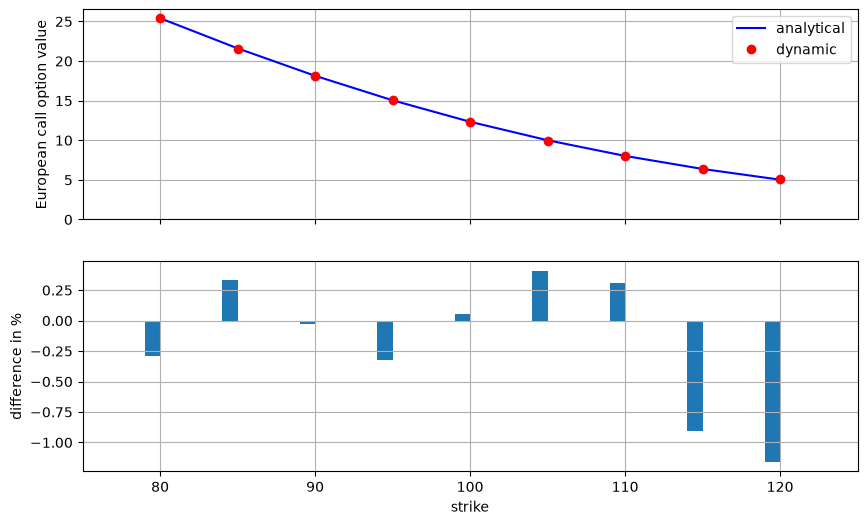

In [77]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,6))

ax1.plot(k_list, anal_res, 'b', label='analytical')
ax1.plot(k_list, dyna_res, 'ro', label='dynamic')
ax1.set_ylabel('European call option value')
ax1.legend(loc=0)
ax1.set_ylim(bottom=0)
ax1.grid(True)

wi = 1.0
ax2.bar(k_list - wi / 2, (anal_res - dyna_res) / anal_res * 100, wi)
ax2.set_xlabel('strike')
ax2.set_ylabel('difference in %')
ax2.set_xlim(left=75, right=125)
ax2.grid(True)

plt.show()

### 12.3.2 아메리칸 옵션

아메리칸 옵션을 평가하는 것은 유러피안 옵션보다 더 복잡.

옵션 가치 계산과 관련하여 **최적 정지 문제**(optimal stopping problem)를 풀어야 함.

아메리칸 옵션 가격 계산을 위한 최적 정지 문제

- $V_0 = \sup\limits_{\tau \in \{0, \Delta t, 2 \Delta t, \dots, T\}} e^{-r \tau} E^Q_0(h_{\tau}(S_{\tau}))$

시뮬레이션상에서 이산 시간 그리드를 사용하여 풀 수 있음.

이렇게 하면 삿리 아메리칸 옵션이 아니라 특정 그리드 점에서 행사가 가능한 버뮤다 옵션 문제를 푸는 셈이지만,

시간 그리드의 간격을 좁히면 아메리칸 옵션으로 수렴.

**최소 자승 몬테카를로**(least-squares Monte Carlo) (LSM) 방법

특점 시간 $t$에 아메리칸(혹은 버뮤다) 옵션의 가치는 $V_t(s) = \max (h_t(s), C_t(s))$

$C_t(s) = E^Q_t ( e^{-rT} V_{t + \Delta t} (S_{t + \Delta t}) | S_t = s)$는 주가 $S_t = s$에서의 옵션 **보유 가치**(continuation value).

주가를 $M$ 개의 동일 시간 간격 $\Delta t$로 시뮬레이션한 경로.

$Y_{t, i} \equiv e^{-rT} V_{t + \Delta t, i}$는 시간 $t$에서 경로 $i$에 대해 시뮬레이션한 보유 가치

이 값을 계산하려면 다음 시간 단계의 보유 가치를 모든 주가에 대해 알아야 함.

최소 자승 몬테카를로 방법은 같은 시간대의 모든 보유 가치 시뮬레이션 값을 계산하기 위해 최소 자승 회귀법을 사용.

기저 함수 집합 $b_d, d = 1, \dots, D$가 주어지면 보유 가치는 $\hat{C_{t, i}} = \sum^D_{d=1} \alpha^*_{d, t} \cdot b_d (S_{t, i})$ 와 같이 회귀 분석으로 주어짐.

회귀 인수 $\alpha^*$는 최소 자승 회귀법으로 구함.

아메리칸 옵션 가치 계산을 위한 최소 자승 회귀법

- $\min_{\alpha_{1,t}, \dots, \alpha_{D, t}} \dfrac{1}{I} \sum\limits_{i=1}^I \left( Y_{t, i} - \sum\limits_{d=1}^{D} \alpha_{d, t} \cdot b_d (S_t{t, i}) \right)^2$

In [78]:
def gbm_mcs_amer(K, option='call'):
    ''' LSM 알고리즘을 이용한 몬테카를로 시뮬레이션을 이용한 아메리칸 옵션의 가치 평가

    인수
    ==========
    K: float
        (양의) 옵션 행사가
    option: string
        가치 평가할 옵션의 유형 ('call', 'put')
    
    반환값
    ==========
    C0: float
        옵션의 현재 가치 추정치
    '''
    dt = T / M
    df = math.exp(-r * dt)

    # 지수 수준의 시뮬레이션
    S = np.zeros((M + 1, I))
    S[0] = S0
    sn = gen_sn(M, I)
    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp((r - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * sn[t])
    
    # 옵션 유형에 따른 페이오프 계산
    if option == 'call':
        h = np.maximum(S - K, 0)
    else:
        h = np.maximum(K - S, 0)
    
    # LSM 알고리즘
    V = np.copy(h)
    for t in range(M - 1, 0, -1):
        reg = np.polyfit(S[t], V[t + 1] * df, 7)
        C = np.polyval(reg, S[t])
        V[t] = np.where(C > h[t], V[t + 1] * df, h[t])
    
    # 몬테카를로 시뮬레이션에 의한 추정치
    C0 = df * np.mean(V[1])

    return C0

In [79]:
gbm_mcs_amer(110., option='call')

np.float64(7.72170560630535)

In [80]:
gbm_mcs_amer(110., option='put')

np.float64(13.609997625418051)

유러피안 옵션 가치는 아메리칸 옵션 가치의 하한(lower bound)이 됨.

두 옵션 가치의 차이는 **조기 행사 프리미엄**(early exercise premium)이라 부름.

In [81]:
euro_res = []
amer_res = []

In [82]:
k_list = np.arange(80, 120.1, 5.)

In [83]:
for K in k_list:
    euro_res.append(gbm_mcs_dyna(K, 'put'))
    amer_res.append(gbm_mcs_amer(K, 'put'))

In [84]:
euro_res = np.array(euro_res)
amer_res = np.array(amer_res)

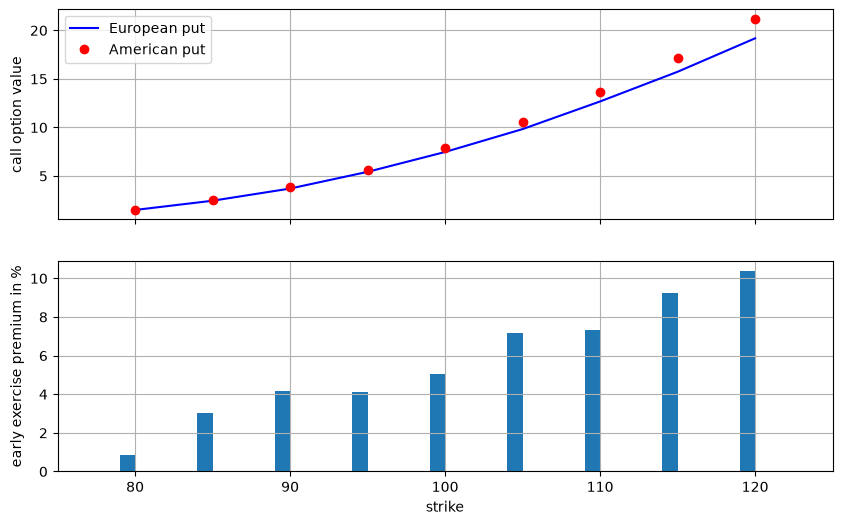

In [85]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,6))

ax1.plot(k_list, euro_res, 'b', label='European put')
ax1.plot(k_list, amer_res, 'ro', label='American put')
ax1.set_ylabel('call option value')
ax1.legend(loc=0)
ax1.grid(True)

wi = 1.0
ax2.bar(k_list - wi / 2, (amer_res - euro_res) / euro_res * 100, wi)
ax2.set_xlabel('strike')
ax2.set_ylabel('early exercise premium in %')
ax2.set_xlim(left=75, right=125)
ax2.grid(True)

plt.show()

## 12.4 위험 측도

확률 과정 시뮬레이션의 중요한 응용 분야 중 하나: **위험 관리**(risk management)

### 12.4.1 VaR

**VaR**(Value-at-Risk): 가장 널리 사용되며 또한 가장 논란이 많은 위험 측도

직관적 vs 이론적 기반, **테일 리스크**(tail risk)를 제대로 파악하지 못함.

Var: 어떤 확률적인 신뢰도하에서 특정 시간 내에 발생할 수 있는 화폐(달러, 유로, 엔 등)로 환산한 포트폴리오나 단일 포지션의 최대 손실 가능 금액

블랙-숄즈-머튼 모형에 기반하여 $T$ = 30 / 365 (30일)라는 미래의 주가를 시뮬레이션

VaR 값을 추정하려면 시뮬레이션상의 손익을 현재 가치와 비교하여 가장 큰 손실부터 가장 큰 수익까지 순서대로 정렬.

In [86]:
S0 = 100
r = 0.05
sigma = 0.25
T = 30 / 365.
I = 10000

In [87]:
ST = S0 * np.exp((r - 0.5 * sigma * sigma) * T + sigma * np.sqrt(T) * npr.standard_normal(I))

In [88]:
R_gbm = np.sort(ST - S0)

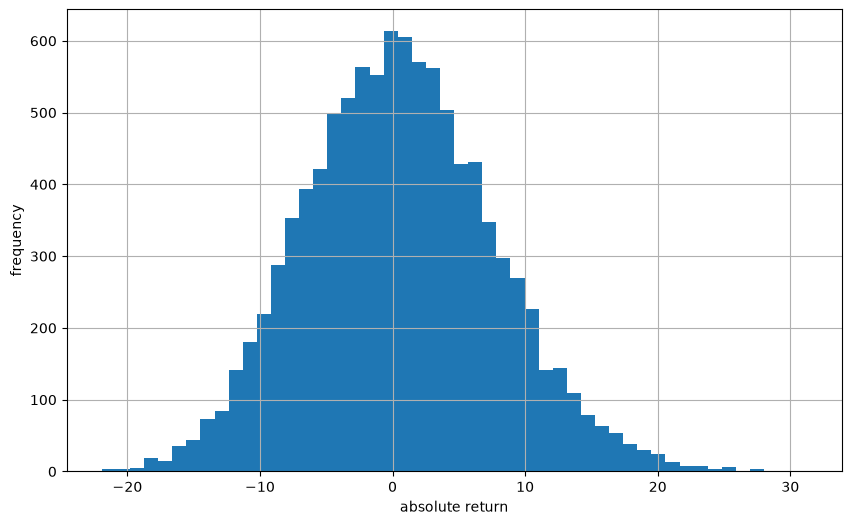

In [89]:
plt.figure(figsize=(10,6))
plt.hist(R_gbm, bins=50)
plt.xlabel('absolute return')
plt.ylabel('frequency')
plt.grid(True)
plt.show()

In [90]:
percs = [0.01, 0.1, 1., 2.5, 5.0, 10.0]
var = scs.scoreatpercentile(R_gbm, percs)
print(f'{'Confidence Level':^16s} | {'Value-at-Risk':^16s}')
print(16 * '-' + '-|-' + 16 * '-')
for pair in zip(percs, var):
    print(f'{100 - pair[0]:>16.2f} | {-pair[1]:>16.3f}')


Confidence Level |  Value-at-Risk  
-----------------|-----------------
           99.99 |           21.814
           99.90 |           18.837
           99.00 |           15.230
           97.50 |           12.816
           95.00 |           10.824
           90.00 |            8.504


머튼의 점프 확산 모형을 동적으로 시뮬레이션

점프 요인이 음수이므로 시뮬레이션 손익은 양봉(bimodal) 분포와 유사한 모습을 보임

정규분포 관점에서 보면 상당한 좌측 **팻 테일**(fat tail)을 가짐.

In [91]:
dt = 30. / 365 / M
rj = lamb * (math.exp(mu + 0.5 * delta * delta) - 1)

In [92]:
S = np.zeros((M + 1, I))
S[0] = S0
sn1 = npr.standard_normal((M + 1, I))
sn2 = npr.standard_normal((M + 1, I))
poi = npr.poisson(lamb * dt, (M + 1, I))
for t in range(1, M + 1):
    S[t] = S[t - 1] * (np.exp((r - rj - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * sn1[t]) + (np.exp(mu + delta * sn2[t]) - 1) * poi[t])
    S[t] = np.maximum(S[t], 0)

In [93]:
R_jd = np.sort(S[-1] - S0)

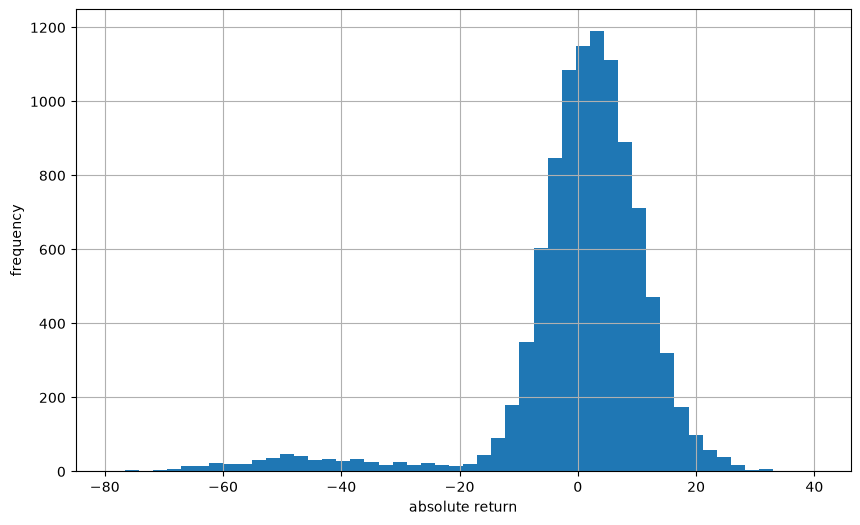

In [94]:
plt.figure(figsize=(10,6))
plt.hist(R_jd, bins=50)
plt.xlabel('absolute return')
plt.ylabel('frequency')
plt.grid(True)
plt.show()

In [95]:
percs = [0.01, 0.1, 1., 2.5, 5.0, 10.0]
var = scs.scoreatpercentile(R_jd, percs)
print(f'{'Confidence Level':^16s} | {'Value-at-Risk':^16s}')
print(16 * '-' + '-|-' + 16 * '-')
for pair in zip(percs, var):
    print(f'{100 - pair[0]:>16.2f} | {-pair[1]:>16.3f}')


Confidence Level |  Value-at-Risk  
-----------------|-----------------
           99.99 |           76.520
           99.90 |           69.396
           99.00 |           55.974
           97.50 |           46.405
           95.00 |           24.198
           90.00 |            8.836


표준적인 VaR 측도로 금융 시장에서 종종 발생하는 테일 리스크를 포착하지 못하는 문제를 보여줌

In [96]:
percs = list(np.arange(0.0, 10.1, 0.1))
gbm_var = scs.scoreatpercentile(R_gbm, percs)
jd_var = scs.scoreatpercentile(R_jd, percs)

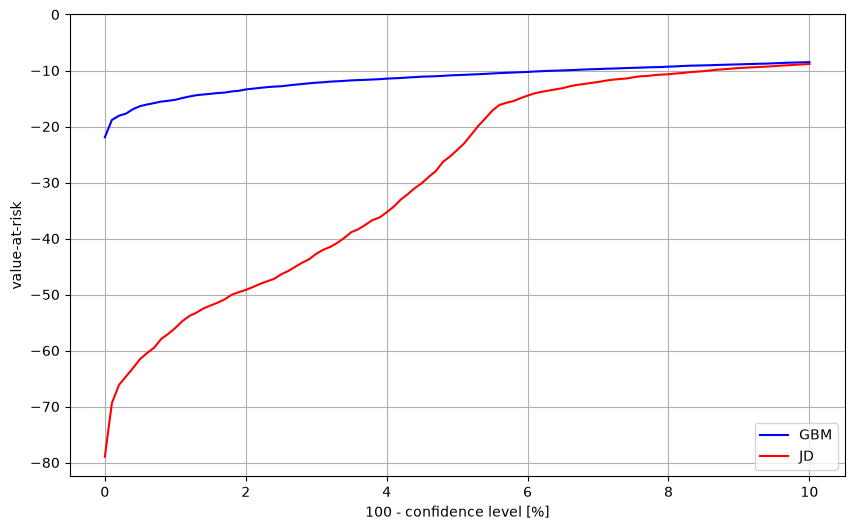

In [97]:
plt.figure(figsize=(10,6))
plt.plot(percs, gbm_var, 'b', lw=1.5, label='GBM')
plt.plot(percs, jd_var, 'r', lw=1.5, label='JD')
plt.legend(loc=4)
plt.xlabel('100 - confidence level [%]')
plt.ylabel('value-at-risk')
plt.ylim(ymax=0.0)
plt.grid(True)
plt.show()

### 12.4.2 CVA

신용 VaR에서 파생된 CVA(credit value adjustment)

신용 VaR는 거래 상대방이 이행의무를 다하지 않을 수 있는 가능성을 고려한 위험 측도.

파산의 경우 **부도 확률**(probability of default)과 **손실 수준**(loss level)의 두 가지 가정이 필요

블랙-숄즈-머튼 모형

가장 단순한 경우로 손실 수준 $L$과 거래 상대방의 1년 부도 확률 $p$로 고정.

부도 시나리오는 포아송 분포를 이용하여 생성, 부도는 한 번만 발생

In [98]:
S0 = 100.
r = 0.05
sigma = 0.2
T = 1.
I = 100000

In [99]:
ST = S0 * np.exp((r - 0.5 * sigma * sigma) * T + sigma * np.sqrt(T) * npr.standard_normal(I))

In [100]:
L = 0.5 # 손실 수준 정의

In [101]:
p = 0.01 # 부도 확률 정의

In [102]:
D = npr.poisson(p * T, I) # 부도 사건 시뮬레이션

In [103]:
D = np.where(D > 1, 1, D) # 값을 1로 제한

In [104]:
math.exp(-r * T) * np.mean(ST) # 시간 T에서 시뮬레이션된 평균 할인 자산 가치

np.float64(99.94767178982691)

In [105]:
CVaR = math.exp(-r * T) * np.mean(L * D * ST)
CVaR # 부도 시 평균 할인 미래 손실

np.float64(0.4883560258963962)

In [106]:
S0_CVA = math.exp(-r * T) * np.mean((1 - L * D) * ST)
S0_CVA # 시간 T에서 시뮬레이션된 평균 할인 자산 가치(부도 손실을 감안하여 조정)

np.float64(99.45931576393053)

In [107]:
S0_adj = S0 - CVaR
S0_adj # 시뮬레이션된 CVaR로 조정된 자산의 현재 가격

np.float64(99.5116439741036)

In [108]:
np.count_nonzero(L * D * ST)

np.int64(978)

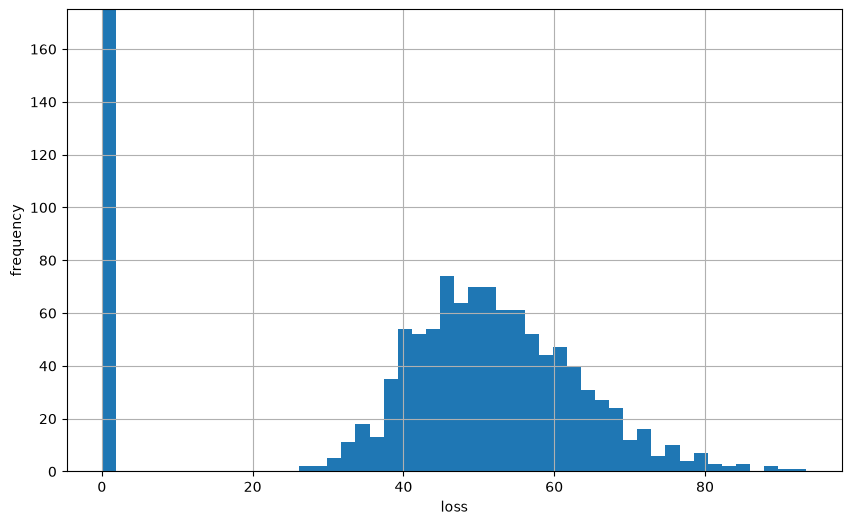

In [109]:
plt.figure(figsize=(10, 6))
plt.hist(L * D * ST, bins=50)
plt.xlabel('loss')
plt.ylabel('frequency')
plt.ylim(ymax=175)
plt.grid()
plt.show()

In [110]:
K = 100.
hT = np.maximum(ST - K, 0)

In [111]:
C0 = math.exp(-r * T) * np.mean(hT)
C0 # 유러피안 콜 옵션에 대한 몬테카를로 추정 가치

np.float64(10.396916492839354)

In [112]:
CVaR = math.exp(-r * T) * np.mean(L * D * hT)
CVaR

np.float64(0.05159099858923534)

In [113]:
C0_CVA = math.exp(-r * T) * np.mean((1 - L * D) * hT)
C0_CVA

np.float64(10.34532549425012)

자산 자체의 경우와 비교하면 옵션의 가치 평가는 약간 다른 특성

자산의 경우에는 부도로 인한 손실이 1,000회 이상

옵션의 경우 500회가 약간 넘을 뿐

이는 옵션의 만기 페이오프가 그 자체로 0이 될 확률이 높기 때문.

In [114]:
np.count_nonzero(L * D * hT) # 부도로 인한 손실의 수

np.int64(538)

In [115]:
np.count_nonzero(D) # 부도의 수

np.int64(978)

In [116]:
I - np.count_nonzero(hT) # 부도로 옵션 가치가 없어지는 경우의 수

np.int64(44123)

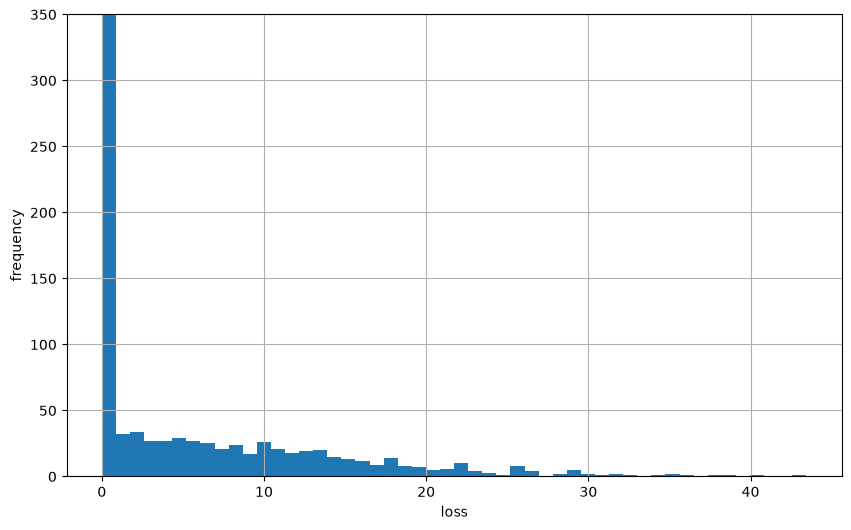

In [117]:
plt.figure(figsize=(10, 6))
plt.hist(L * D * hT, bins=50)
plt.xlabel('loss')
plt.ylabel('frequency')
plt.ylim(ymax=350)
plt.grid()
plt.show()